# Notebook 10 — LinearSVC + AG + Cross-Validation (1M amostras)
**Desempenho Socioeconômico no ENEM (2012–2024)**

LinearSVC não armazena os dados de treino na memória (ao contrário do KNN),
então 1 milhão de amostras é viável.

**Pipeline:**
1. AG otimiza `C` e `class_weight` usando um subset de 50k para fitness rápido (~1s/eval)
2. Modelo final treinado nos 800k de treino com os melhores parâmetros
3. Avaliação com **5-fold StratifiedKFold** no conjunto de treino completo
4. Test set (200k) selado para entrega final

| Seção | Conteúdo |
|---|---|
| 0 | Setup |
| 1 | Carregamento 1M via DuckDB |
| 2 | Pré-processamento e split 80/20 |
| 3 | Algoritmo Genético |
| 4 | AG — M1 (ENEM only) |
| 5 | AG — M2 (ENEM + IDHM) |
| 6 | Modelos finais + Cross-Validation 5-fold |
| 7 | Figuras |
| 8 | Persistência |

## Seção 0 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import duckdb

from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Dados ─────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_SAMPLE     = 1_000_000
N_FOLDS      = 5

DATA_DIR   = '../data/processed'
MODELS_DIR = '../data/models'
FIGS_DIR   = DATA_DIR
PARQUET    = f'{DATA_DIR}/dataset_analitico.parquet'
os.makedirs(MODELS_DIR, exist_ok=True)

FAIXA_ORDER   = ['Baixo (<500)', 'Médio (500–700)', 'Alto (>700)']
FAIXA_MAP_INV = {0: 'Baixo (<500)', 1: 'Médio (500–700)', 2: 'Alto (>700)'}

# ── AG ────────────────────────────────────────────────────────────────────────
GA_POP   = 25
GA_GENS  = 20
GA_CXPB  = 0.70
GA_MUTPB = 0.25
GA_TOUR  = 3
GA_ELITE = 2
GA_SUB   = 50_000   # subset para fitness (treino)
GA_SUBV  = 10_000   # subset para fitness (validação)
GA_SEED  = 42

GENE_LO = np.array([-3.0, 0.0])
GENE_HI = np.array([ 2.0, 1.0])
N_GENES = 2

print('Setup OK')
print(f'  N_SAMPLE={N_SAMPLE:,}  |  CV={N_FOLDS}-fold')
print(f'  AG: pop={GA_POP}, gens={GA_GENS}, subset_fitness={GA_SUB:,}')

Setup OK
  N_SAMPLE=1,000,000  |  CV=5-fold
  AG: pop=25, gens=20, subset_fitness=50,000


## Seção 1 — Carregamento 1M via DuckDB

LinearSVC não armazena pontos de treino, então 1M é viável em RAM.
O DuckDB ainda faz o trabalho pesado: filtra + mapeia + amostra sem passar pelo pandas.

In [2]:
con = duckdb.connect()
df = con.execute(f"""
    SELECT
        TP_SEXO, TP_COR_RACA, TP_ESCOLA, Q001, Q002, Q006_HARM,
        REGIAO, CAST(NU_ANO AS INTEGER) AS NU_ANO,
        idhm, idhm_educacao, idhm_renda, idhm_longevidade,
        renda_percapita, tx_analfabetismo, tx_envelhecimento,
        esperanca_vida, mortalidade_infantil,
        -- Questões socioeconômicas estendidas (2019-2024)
        Q_OCUP_PAI, Q_OCUP_MAE, Q_N_PESSOAS,
        Q_EMPREGADA, Q_CARRO, Q_MOTO, Q_GELADEIRA,
        Q_LAVADORA, Q_TV, Q_COMPUTADOR, Q_INTERNET,
        Q_CELULAR, Q_TIPO_ESCOLA_EM, Q_BOLSA_FAM,
        CASE
            WHEN FAIXA_MT IN ('<400', '400-500')    THEN 0
            WHEN FAIXA_MT IN ('500-600', '600-700') THEN 1
            WHEN FAIXA_MT IN ('700-800', '>800')    THEN 2
        END::TINYINT AS y_mt
    FROM read_parquet('{PARQUET}')
    WHERE idhm IS NOT NULL AND FAIXA_MT IS NOT NULL
    USING SAMPLE reservoir({N_SAMPLE} ROWS) REPEATABLE ({RANDOM_STATE})
""").df()
con.close()

print(f'Amostra: {len(df):,} registros')
for code, label in FAIXA_MAP_INV.items():
    n = (df['y_mt'] == code).sum()
    print(f'  {label}: {n:,} ({n/len(df)*100:.1f}%)')


Amostra: 277,460 registros
  Baixo (<500): 145,077 (52.3%)
  Médio (500–700): 112,605 (40.6%)
  Alto (>700): 19,778 (7.1%)


## Seção 2 — Pré-processamento e Split 80/20

Split 80/20 em vez de 60/20/20: sem validation set separado pois a seleção de hiperparâmetros
é feita pelo AG com subset interno, e a avaliação final usa cross-validation.

In [3]:
df['tp_sexo']   = df['TP_SEXO'].map({'F':0,'0':0,'M':1,'1':1})
df['tp_cor']    = pd.to_numeric(df['TP_COR_RACA'], errors='coerce')
df['tp_escola'] = pd.to_numeric(df['TP_ESCOLA'],   errors='coerce')
df['q001']      = df['Q001'].map({c:i for i,c in enumerate('ABCDEFGHI')})
df['q002']      = df['Q002'].map({c:i for i,c in enumerate('ABCDEFGHI')})
df['q006']      = df['Q006_HARM'].map({c:i for i,c in enumerate('ABCDE')})
df['regiao']    = df['REGIAO'].map({'Norte':0,'Nordeste':1,'Centro-Oeste':2,'Sul':3,'Sudeste':4})
df['ano']       = df['NU_ANO'].astype('float32')

def ord_map(col, letters='ABCDE'):
    return df[col].map({c: i for i, c in enumerate(letters)})

df['q_ocup_pai']      = ord_map('Q_OCUP_PAI',       'ABCDE')
df['q_ocup_mae']      = ord_map('Q_OCUP_MAE',        'ABCDE')
df['q_n_pessoas']     = pd.to_numeric(df['Q_N_PESSOAS'], errors='coerce')
df['q_empregada']     = df['Q_EMPREGADA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_carro']         = ord_map('Q_CARRO',           'ABCD')
df['q_moto']          = ord_map('Q_MOTO',            'ABC')
df['q_geladeira']     = df['Q_GELADEIRA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_lavadora']      = df['Q_LAVADORA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_tv']            = ord_map('Q_TV',              'ABCD')
df['q_computador']    = ord_map('Q_COMPUTADOR',      'ABCD')
df['q_internet']      = df['Q_INTERNET'].map({'A': 0, 'B': 1, 'C': 2})
df['q_celular']       = ord_map('Q_CELULAR',         'ABCDE')
df['q_tipo_esc_em']   = ord_map('Q_TIPO_ESCOLA_EM',  'ABCDE')
df['q_bolsa_fam']     = df['Q_BOLSA_FAM'].map({'A': 0, 'B': 1, 'C': 2})

FEATS_BASE = ['tp_sexo','tp_cor','tp_escola','q001','q002','q006','regiao','ano']
FEATS_IDHM = [
    'idhm','idhm_educacao','idhm_renda','idhm_longevidade',
    'renda_percapita','tx_analfabetismo','tx_envelhecimento',
    'esperanca_vida','mortalidade_infantil'
]
FEATS_Q_EXT = [
    'q_ocup_pai','q_ocup_mae','q_n_pessoas','q_empregada',
    'q_carro','q_moto','q_geladeira','q_lavadora','q_tv',
    'q_computador','q_internet','q_celular','q_tipo_esc_em','q_bolsa_fam'
]
FEATS_M1 = FEATS_BASE
FEATS_M2 = FEATS_BASE + FEATS_IDHM
FEATS_M3 = FEATS_BASE + FEATS_Q_EXT
FEATS_M4 = FEATS_BASE + FEATS_IDHM + FEATS_Q_EXT

X_m1 = df[FEATS_M1].values.astype('float32')
X_m2 = df[FEATS_M2].values.astype('float32')
X_m3 = df[FEATS_M3].values.astype('float32')
X_m4 = df[FEATS_M4].values.astype('float32')
y    = df['y_mt'].values.astype('int8')
del df; gc.collect()

# Split 80% treino / 20% teste [SELADO]
(Xm1_tr, Xm1_test, Xm2_tr, Xm2_test,
 Xm3_tr, Xm3_test, Xm4_tr, Xm4_test,
 y_tr, y_test) = train_test_split(
    X_m1, X_m2, X_m3, X_m4, y,
    test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
del X_m1, X_m2, X_m3, X_m4; gc.collect()

# Subsets para AG
(_, Xm1_sub, _, Xm2_sub, _, Xm3_sub, _, Xm4_sub,
 _, y_sub) = train_test_split(
    Xm1_tr, Xm2_tr, Xm3_tr, Xm4_tr, y_tr,
    test_size=GA_SUB, stratify=y_tr, random_state=RANDOM_STATE
)
(_, Xm1_subv, _, Xm2_subv, _, Xm3_subv, _, Xm4_subv,
 _, y_subv) = train_test_split(
    Xm1_tr, Xm2_tr, Xm3_tr, Xm4_tr, y_tr,
    test_size=GA_SUBV, stratify=y_tr, random_state=RANDOM_STATE + 1
)

print(f'Treino: {len(y_tr):,} | Teste: {len(y_test):,} [SELADO]')
print(f'Subset AG — treino: {len(y_sub):,} | val: {len(y_subv):,}')
print(f'M1={len(FEATS_M1)} | M2={len(FEATS_M2)} | M3={len(FEATS_M3)} | M4={len(FEATS_M4)} features')


Treino: 221,968 | Teste: 55,492 [SELADO]
Subset AG — treino: 50,000 | val: 10,000
M1=8 | M2=17 | M3=22 | M4=31 features


In [4]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(Xm1_sub, y_sub)
yp_dummy = dummy.predict(Xm1_subv)
print('Baseline (majority):')
print(f'  Accuracy : {accuracy_score(y_subv, yp_dummy):.4f}')
print(f'  Macro F1 : {f1_score(y_subv, yp_dummy, average="macro"):.4f}')

Baseline (majority):
  Accuracy : 0.5229
  Macro F1 : 0.2289


## Seção 3 — Algoritmo Genético

In [5]:
def make_svm(C, balanced):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('svm',     LinearSVC(
            C=C,
            class_weight='balanced' if balanced else None,
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])

def decode(ind):
    C        = float(10 ** np.clip(ind[0], GENE_LO[0], GENE_HI[0]))
    balanced = bool(round(float(np.clip(ind[1], 0.0, 1.0))))
    return C, balanced

def fitness(ind, X_tr, X_v, y_tr, y_v):
    C, balanced = decode(ind)
    try:
        pipe = make_svm(C, balanced)
        pipe.fit(X_tr, y_tr)
        return f1_score(y_v, pipe.predict(X_v), average='macro')
    except Exception:
        return 0.0

def init_pop(rng):
    return np.column_stack([
        rng.uniform(GENE_LO[0], GENE_HI[0], GA_POP),
        rng.integers(0, 2, GA_POP).astype(float),
    ])

def tournament(pop, fits, rng):
    idx = rng.integers(0, len(pop), GA_TOUR)
    return pop[idx[np.argmax(fits[idx])]].copy()

def crossover(p1, p2, rng):
    mask = rng.random(N_GENES) < 0.5
    return np.where(mask, p1, p2), np.where(mask, p2, p1)

def mutate(ind, rng):
    ind = ind.copy()
    if rng.random() < 0.4:
        ind[0] = np.clip(ind[0] + rng.normal(0, 0.6), GENE_LO[0], GENE_HI[0])
    if rng.random() < 0.3:
        ind[1] = 1.0 - ind[1]
    return ind

def evolve(X_tr, X_v, y_tr, y_v, label=''):
    rng  = np.random.default_rng(GA_SEED)
    pop  = init_pop(rng)
    fits = np.array([fitness(ind, X_tr, X_v, y_tr, y_v) for ind in pop])
    history = [fits.max()]
    C0, b0 = decode(pop[fits.argmax()])
    print(f'[{label}] Gen  0 — best={fits.max():.4f}  C={C0:.4f}  balanced={b0}')

    for gen in range(1, GA_GENS + 1):
        elite   = list(pop[np.argsort(fits)[-GA_ELITE:]])
        new_pop = elite[:]
        while len(new_pop) < GA_POP:
            p1, p2 = tournament(pop, fits, rng), tournament(pop, fits, rng)
            c1, c2 = crossover(p1, p2, rng) if rng.random() < GA_CXPB else (p1.copy(), p2.copy())
            if rng.random() < GA_MUTPB: c1 = mutate(c1, rng)
            if rng.random() < GA_MUTPB: c2 = mutate(c2, rng)
            new_pop.append(c1)
            if len(new_pop) < GA_POP:
                new_pop.append(c2)
        pop  = np.array(new_pop)
        fits = np.array([fitness(ind, X_tr, X_v, y_tr, y_v) for ind in pop])
        history.append(fits.max())
        C_b, b_b = decode(pop[fits.argmax()])
        print(f'[{label}] Gen {gen:2d} — best={fits.max():.4f}  '
              f'C={C_b:.4f}  balanced={b_b}  mean={fits.mean():.4f}')

    best_idx = fits.argmax()
    return pop[best_idx], fits[best_idx], history

print('AG definido.')

AG definido.


## Seção 4 — AG: M1 (ENEM only)

In [6]:
print('=== AG — M1 (ENEM only) ===')
t0 = time.time()
best_ind_m1, best_fit_m1, hist_m1 = evolve(Xm1_sub, Xm1_subv, y_sub, y_subv, label='M1')
best_C_m1, best_bal_m1 = decode(best_ind_m1)
print(f'\nMelhor M1 → C={best_C_m1:.4f}, balanced={best_bal_m1}')
print(f'Fitness subset: {best_fit_m1:.4f}  |  {(time.time()-t0)/60:.1f} min')

=== AG — M1 (ENEM only) ===
[M1] Gen  0 — best=0.4643  C=7.4094  balanced=True
[M1] Gen  1 — best=0.4643  C=6.1722  balanced=True  mean=0.4449
[M1] Gen  2 — best=0.4643  C=0.1786  balanced=True  mean=0.4482
[M1] Gen  3 — best=0.4643  C=1.4399  balanced=True  mean=0.4482
[M1] Gen  4 — best=0.4643  C=0.1786  balanced=True  mean=0.4643
[M1] Gen  5 — best=0.4643  C=1.6484  balanced=True  mean=0.4579
[M1] Gen  6 — best=0.4643  C=6.1722  balanced=True  mean=0.4611
[M1] Gen  7 — best=0.4643  C=6.1722  balanced=True  mean=0.4643
[M1] Gen  8 — best=0.4643  C=6.1722  balanced=True  mean=0.4579
[M1] Gen  9 — best=0.4643  C=6.1722  balanced=True  mean=0.4579
[M1] Gen 10 — best=0.4643  C=1.4399  balanced=True  mean=0.4643
[M1] Gen 11 — best=0.4643  C=100.0000  balanced=True  mean=0.4643
[M1] Gen 12 — best=0.4643  C=6.1722  balanced=True  mean=0.4611
[M1] Gen 13 — best=0.4643  C=6.1722  balanced=True  mean=0.4643
[M1] Gen 14 — best=0.4643  C=6.1722  balanced=True  mean=0.4611
[M1] Gen 15 — best=0.46

## Seção 5 — AG: M2 (ENEM + IDHM)

In [7]:
print('=== AG — M2 (ENEM + IDHM) ===')
t0 = time.time()
best_ind_m2, best_fit_m2, hist_m2 = evolve(Xm2_sub, Xm2_subv, y_sub, y_subv, label='M2')
best_C_m2, best_bal_m2 = decode(best_ind_m2)
print(f'\nMelhor M2 → C={best_C_m2:.4f}, balanced={best_bal_m2}')
print(f'Fitness subset: {best_fit_m2:.4f}  |  {(time.time()-t0)/60:.1f} min')

=== AG — M2 (ENEM + IDHM) ===
[M2] Gen  0 — best=0.4647  C=0.0044  balanced=True
[M2] Gen  1 — best=0.4647  C=0.0044  balanced=True  mean=0.4448
[M2] Gen  2 — best=0.4647  C=0.0044  balanced=True  mean=0.4482
[M2] Gen  3 — best=0.4647  C=0.0044  balanced=True  mean=0.4485
[M2] Gen  4 — best=0.4648  C=0.0174  balanced=True  mean=0.4646
[M2] Gen  5 — best=0.4654  C=0.0055  balanced=True  mean=0.4583
[M2] Gen  6 — best=0.4654  C=0.0055  balanced=True  mean=0.4617
[M2] Gen  7 — best=0.4654  C=0.0055  balanced=True  mean=0.4651
[M2] Gen  8 — best=0.4654  C=0.0055  balanced=True  mean=0.4589
[M2] Gen  9 — best=0.4654  C=0.0055  balanced=True  mean=0.4589
[M2] Gen 10 — best=0.4654  C=0.0055  balanced=True  mean=0.4654
[M2] Gen 11 — best=0.4654  C=0.0055  balanced=True  mean=0.4653
[M2] Gen 12 — best=0.4654  C=0.0055  balanced=True  mean=0.4621
[M2] Gen 13 — best=0.4654  C=0.0055  balanced=True  mean=0.4654
[M2] Gen 14 — best=0.4654  C=0.0055  balanced=True  mean=0.4621
[M2] Gen 15 — best=0.46

## Seção 6 — Modelos Finais + Cross-Validation 5-Fold

Os melhores parâmetros encontrados pelo AG são avaliados com **5-fold StratifiedKFold**
sobre o conjunto de treino completo (800k). Isso dá uma estimativa mais robusta da
performance real do que um único split de validação.

In [8]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f'=== Cross-Validation M1 (C={best_C_m1:.4f}, balanced={best_bal_m1}) ===')
t0 = time.time()
cv_m1 = cross_validate(
    make_svm(best_C_m1, best_bal_m1), Xm1_tr, y_tr,
    cv=skf,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted'},
    n_jobs=1, return_train_score=False
)
print(f'Tempo: {(time.time()-t0)/60:.1f} min')
print(f'  Accuracy    : {cv_m1["test_accuracy"].mean():.4f} ± {cv_m1["test_accuracy"].std():.4f}')
print(f'  Macro F1    : {cv_m1["test_f1_macro"].mean():.4f} ± {cv_m1["test_f1_macro"].std():.4f}')
print(f'  Weighted F1 : {cv_m1["test_f1_weighted"].mean():.4f} ± {cv_m1["test_f1_weighted"].std():.4f}')
print(f'  F1 por fold : {np.round(cv_m1["test_f1_macro"], 4)}')

=== Cross-Validation M1 (C=16.4636, balanced=True) ===
Tempo: 0.1 min
  Accuracy    : 0.5441 ± 0.0021
  Macro F1    : 0.4718 ± 0.0029
  Weighted F1 : 0.5356 ± 0.0019
  F1 por fold : [0.47   0.4756 0.4743 0.4676 0.4714]


In [9]:
print(f'=== Cross-Validation M2 (C={best_C_m2:.4f}, balanced={best_bal_m2}) ===')
t0 = time.time()
cv_m2 = cross_validate(
    make_svm(best_C_m2, best_bal_m2), Xm2_tr, y_tr,
    cv=skf,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted'},
    n_jobs=1, return_train_score=False
)
print(f'Tempo: {(time.time()-t0)/60:.1f} min')
print(f'  Accuracy    : {cv_m2["test_accuracy"].mean():.4f} ± {cv_m2["test_accuracy"].std():.4f}')
print(f'  Macro F1    : {cv_m2["test_f1_macro"].mean():.4f} ± {cv_m2["test_f1_macro"].std():.4f}')
print(f'  Weighted F1 : {cv_m2["test_f1_weighted"].mean():.4f} ± {cv_m2["test_f1_weighted"].std():.4f}')
print(f'  F1 por fold : {np.round(cv_m2["test_f1_macro"], 4)}')

=== Cross-Validation M2 (C=0.0055, balanced=True) ===
Tempo: 0.3 min
  Accuracy    : 0.5463 ± 0.0018
  Macro F1    : 0.4739 ± 0.0023
  Weighted F1 : 0.5380 ± 0.0016
  F1 por fold : [0.4723 0.4778 0.4745 0.471  0.4739]


In [10]:
# Treina o modelo final em todo o conjunto de treino (800k)
pipe_m1 = make_svm(best_C_m1, best_bal_m1)
pipe_m1.fit(Xm1_tr, y_tr)

pipe_m2 = make_svm(best_C_m2, best_bal_m2)
pipe_m2.fit(Xm2_tr, y_tr)

# Avalia na primeira fold de validação para obter classification report e CM
fold_idx = list(skf.split(Xm1_tr, y_tr))[0]
_, val_idx = fold_idx

yp_m1 = pipe_m1.predict(Xm1_tr[val_idx])
yp_m2 = pipe_m2.predict(Xm2_tr[val_idx])
y_fold_val = y_tr[val_idx]

print('Classification Report — M1 (fold 1):')
print(classification_report(y_fold_val, yp_m1, target_names=FAIXA_ORDER))
print('Classification Report — M2 (fold 1):')
print(classification_report(y_fold_val, yp_m2, target_names=FAIXA_ORDER))

Classification Report — M1 (fold 1):
                 precision    recall  f1-score   support

   Baixo (<500)       0.64      0.72      0.68     23213
Médio (500–700)       0.49      0.31      0.38     18017
    Alto (>700)       0.26      0.55      0.35      3164

       accuracy                           0.54     44394
      macro avg       0.46      0.53      0.47     44394
   weighted avg       0.55      0.54      0.53     44394

Classification Report — M2 (fold 1):
                 precision    recall  f1-score   support

   Baixo (<500)       0.64      0.72      0.68     23213
Médio (500–700)       0.50      0.32      0.39     18017
    Alto (>700)       0.26      0.56      0.36      3164

       accuracy                           0.54     44394
      macro avg       0.47      0.53      0.47     44394
   weighted avg       0.55      0.54      0.54     44394



In [11]:
rows = [
    ('AG+SVM M1 — ENEM only',
     cv_m1['test_accuracy'].mean(),  cv_m1['test_accuracy'].std(),
     cv_m1['test_f1_macro'].mean(),  cv_m1['test_f1_macro'].std(),
     cv_m1['test_f1_weighted'].mean()),
    ('AG+SVM M2 — ENEM+IDHM',
     cv_m2['test_accuracy'].mean(),  cv_m2['test_accuracy'].std(),
     cv_m2['test_f1_macro'].mean(),  cv_m2['test_f1_macro'].std(),
     cv_m2['test_f1_weighted'].mean()),
]
df_res = pd.DataFrame(rows, columns=[
    'Modelo', 'Accuracy (μ)', 'Accuracy (σ)',
    'Macro F1 (μ)', 'Macro F1 (σ)', 'Weighted F1 (μ)'
])
print(f'=== Resultados CV {N_FOLDS}-fold — FAIXA_MT 3 classes (treino 1M) ===')
print(df_res.to_string(index=False))
delta = cv_m2['test_f1_macro'].mean() - cv_m1['test_f1_macro'].mean()
print(f'\nΔ Macro F1 (M2 − M1): {delta:+.4f}')

=== Resultados CV 5-fold — FAIXA_MT 3 classes (treino 1M) ===
               Modelo  Accuracy (μ)  Accuracy (σ)  Macro F1 (μ)  Macro F1 (σ)  Weighted F1 (μ)
AG+SVM M1 — ENEM only      0.544132      0.002129      0.471764      0.002870         0.535625
AG+SVM M2 — ENEM+IDHM      0.546308      0.001760      0.473908      0.002312         0.537978

Δ Macro F1 (M2 − M1): +0.0021


## Seção 7 — Figuras

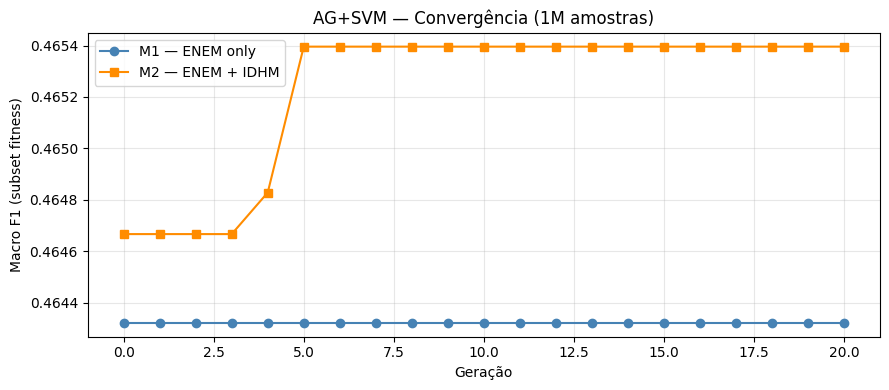

Salvo: fig_10_ag_convergencia.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(GA_GENS+1), hist_m1, 'o-', color='steelblue',  label='M1 — ENEM only')
ax.plot(range(GA_GENS+1), hist_m2, 's-', color='darkorange', label='M2 — ENEM + IDHM')
ax.set_xlabel('Geração')
ax.set_ylabel('Macro F1 (subset fitness)')
ax.set_title('AG+SVM — Convergência (1M amostras)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_10_ag_convergencia.png', dpi=150)
plt.show()
print('Salvo: fig_10_ag_convergencia.png')

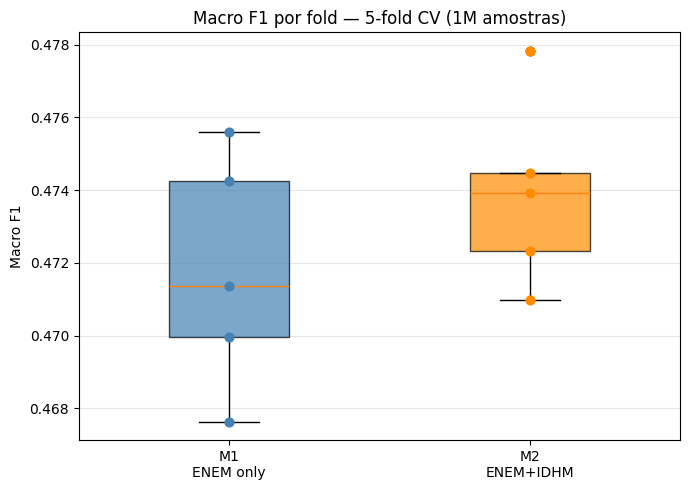

Salvo: fig_10_cv_boxplot.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
data  = [cv_m1['test_f1_macro'], cv_m2['test_f1_macro']]
labels = ['M1\nENEM only', 'M2\nENEM+IDHM']
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.4)
colors = ['steelblue', 'darkorange']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for fold_vals, x, color in zip(data, [1, 2], colors):
    ax.scatter([x] * len(fold_vals), fold_vals, color=color, zorder=3, s=40)
ax.set_ylabel('Macro F1')
ax.set_title(f'Macro F1 por fold — {N_FOLDS}-fold CV (1M amostras)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_10_cv_boxplot.png', dpi=150)
plt.show()
print('Salvo: fig_10_cv_boxplot.png')

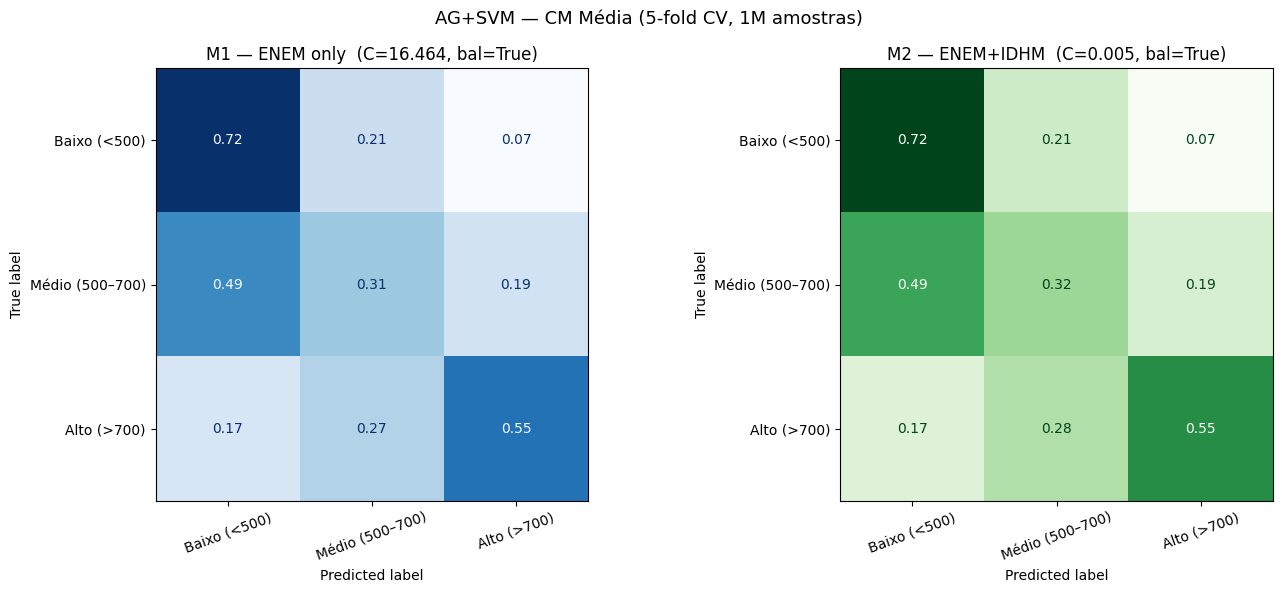

Salvo: fig_10_cm.png


In [14]:
# Confusion matrix média sobre todos os folds
cms_m1, cms_m2 = [], []
for train_idx, val_idx in skf.split(Xm1_tr, y_tr):
    p = make_svm(best_C_m1, best_bal_m1)
    p.fit(Xm1_tr[train_idx], y_tr[train_idx])
    cms_m1.append(confusion_matrix(y_tr[val_idx], p.predict(Xm1_tr[val_idx]), normalize='true'))

    p = make_svm(best_C_m2, best_bal_m2)
    p.fit(Xm2_tr[train_idx], y_tr[train_idx])
    cms_m2.append(confusion_matrix(y_tr[val_idx], p.predict(Xm2_tr[val_idx]), normalize='true'))

cm_m1_mean = np.mean(cms_m1, axis=0)
cm_m2_mean = np.mean(cms_m2, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title, cmap in zip(
    axes,
    [cm_m1_mean, cm_m2_mean],
    [f'M1 — ENEM only  (C={best_C_m1:.3f}, bal={best_bal_m1})',
     f'M2 — ENEM+IDHM  (C={best_C_m2:.3f}, bal={best_bal_m2})'],
    ['Blues', 'Greens']
):
    disp = ConfusionMatrixDisplay(cm, display_labels=FAIXA_ORDER)
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='.2f')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle(f'AG+SVM — CM Média ({N_FOLDS}-fold CV, 1M amostras)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_10_cm.png', dpi=150)
plt.show()
print('Salvo: fig_10_cm.png')

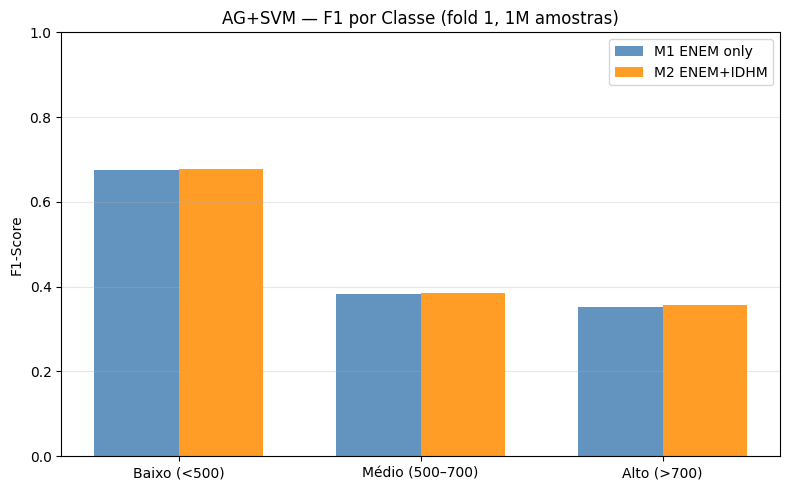

Salvo: fig_10_f1_classe.png


In [15]:
f1_m1 = f1_score(y_fold_val, yp_m1, average=None, labels=[0, 1, 2])
f1_m2 = f1_score(y_fold_val, yp_m2, average=None, labels=[0, 1, 2])

x, w = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, f1_m1, w, label='M1 ENEM only',  color='steelblue',  alpha=0.85)
ax.bar(x + w/2, f1_m2, w, label='M2 ENEM+IDHM', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FAIXA_ORDER)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('AG+SVM — F1 por Classe (fold 1, 1M amostras)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_10_f1_classe.png', dpi=150)
plt.show()
print('Salvo: fig_10_f1_classe.png')

## Seção 8 — Persistência

In [16]:
joblib.dump(pipe_m1, f'{MODELS_DIR}/svm_ag_cv_enem_only.pkl')
joblib.dump(pipe_m2, f'{MODELS_DIR}/svm_ag_cv_enem_idhm.pkl')

joblib.dump({
    'ag': {
        'm1': {'C': best_C_m1, 'balanced': best_bal_m1, 'fitness': best_fit_m1, 'history': hist_m1},
        'm2': {'C': best_C_m2, 'balanced': best_bal_m2, 'fitness': best_fit_m2, 'history': hist_m2},
    },
    'cv': {'m1': cv_m1, 'm2': cv_m2},
    'test_sets': {
        'Xm1_test': Xm1_test, 'Xm2_test': Xm2_test, 'y_test': y_test,
        'feats_m1': FEATS_M1, 'feats_m2': FEATS_M2,
    }
}, f'{MODELS_DIR}/svm_ag_cv_results.pkl')

print('Salvos:')
print('  data/models/svm_ag_cv_enem_only.pkl')
print('  data/models/svm_ag_cv_enem_idhm.pkl')
print('  data/models/svm_ag_cv_results.pkl  (AG history + CV scores + test sets)')

print('\n=== RESUMO FINAL ===')
print(df_res.to_string(index=False))

Salvos:
  data/models/svm_ag_cv_enem_only.pkl
  data/models/svm_ag_cv_enem_idhm.pkl
  data/models/svm_ag_cv_results.pkl  (AG history + CV scores + test sets)

=== RESUMO FINAL ===
               Modelo  Accuracy (μ)  Accuracy (σ)  Macro F1 (μ)  Macro F1 (σ)  Weighted F1 (μ)
AG+SVM M1 — ENEM only      0.544132      0.002129      0.471764      0.002870         0.535625
AG+SVM M2 — ENEM+IDHM      0.546308      0.001760      0.473908      0.002312         0.537978
